In [8]:
import pandas as pd
df_train = pd.read_csv('mnist_train.csv')
df_test = pd.read_csv('mnist_test.csv')
print(df_train.shape)
print(df_test.shape)

(60000, 785)
(10000, 785)


<font color = 'red' size = 5>Ready the Data</font>

In [9]:
X_train = df_train.drop("label", axis=1)  #data
y_train = df_train["label"] #target

X_test = df_test.drop("label", axis=1) #test data
y_test = df_test["label"] #test target

<font color = 'orange' size = 5>Preprocessing</font>

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<font color = 'yellow' size = 5>Trainig SVM</font>

In [11]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=5, gamma="scale")
svm_model.fit(X_train_scaled, y_train)

SVC(C=5)

<font size = 5 color ='lightgreen'>Predictions</font>

In [12]:
#Accuracy: Overall percentage of correct predictions.
from sklearn.metrics import accuracy_score
y_pred = svm_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9727


In [13]:
#Confusion Matrix: Provides a breakdown of correct/incorrect predictions for each digit.
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)



Confusion Matrix:
[[ 966    0    3    3    1    2    3    1    1    0]
 [   0 1127    3    0    0    1    2    1    1    0]
 [   5    3 1001    0    1    0    1   13    7    1]
 [   0    0    4  986    1    6    0    8    4    1]
 [   0    0    9    0  951    2    3    7    2    8]
 [   2    0    2    8    2  862    4    6    5    1]
 [   5    2    1    0    3    8  935    2    2    0]
 [   0    5   10    2    2    1    0 1000    0    8]
 [   2    0    4    5    5    7    0   12  935    4]
 [   1    3    4    8   10    3    0   14    2  964]]


In [14]:
#Classification Report: Detailed precision, recall, and F1-score for each digit.
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.97      0.98      0.98      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.97      0.97       892
           6       0.99      0.98      0.98       958
           7       0.94      0.97      0.96      1028
           8       0.97      0.96      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



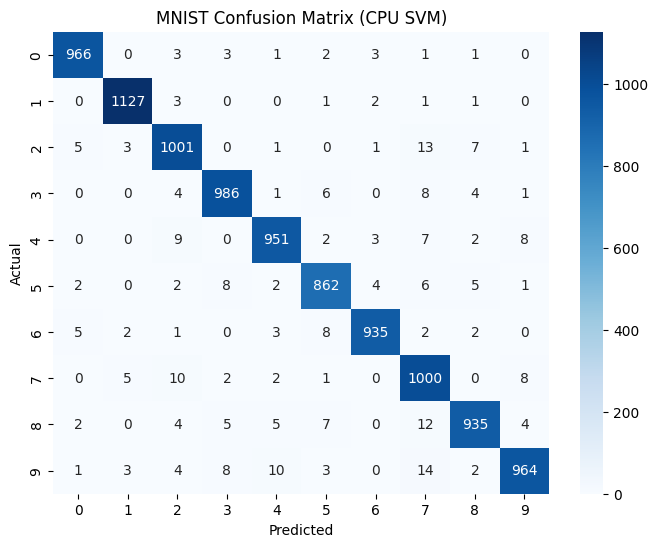

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix (CPU SVM)")
plt.show()


In [ ]:
#Macro Average: Average precision, recall, and F1-score across all digits, treating each digit equally.
from sklearn.metrics import precision_score, recall_score, f1_score
#Doesnt care about class imbalance
precision_macro = precision_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")
f1_macro = f1_score(y_test, y_pred, average="macro")

print("Macro Average:")
print("Precision:", precision_macro)
print("Recall:", recall_macro)
print("F1 Score:", f1_macro)


Macro Average:
Precision: 0.9727750175786192
Recall: 0.9723778791469828
F1 Score: 0.9725245345256758


In [17]:
#Micro Average: Average precision, recall, and F1-score across all digits, treating each prediction equally.
precision_micro = precision_score(y_test, y_pred, average="micro")
recall_micro = recall_score(y_test, y_pred, average="micro")
f1_micro = f1_score(y_test, y_pred, average="micro")

print("\nMicro Average:")
print("Precision:", precision_micro)
print("Recall:", recall_micro)
print("F1 Score:", f1_micro)



Micro Average:
Precision: 0.9727
Recall: 0.9727
F1 Score: 0.9727


In [18]:
#Weighted Average: Average precision, recall, and F1-score across all digits, weighted by the number of true instances for each digit.
precision_weighted = precision_score(y_test, y_pred, average="weighted")
recall_weighted = recall_score(y_test, y_pred, average="weighted")
f1_weighted = f1_score(y_test, y_pred, average="weighted")
#Accounts for class frequencies
print("\nWeighted Average:")
print("Precision:", precision_weighted)
print("Recall:", recall_weighted)
print("F1 Score:", f1_weighted)



Weighted Average:
Precision: 0.9728456051323503
Recall: 0.9727
F1 Score: 0.9727201481908363
